## Why Last Names Matter

When I played soccer as a little kid, everything was alphabetized. Roll call, jersey distribution, first dibs at snacktime... the list goes on. If your last name started with A, you were always first, and if it started with Z, you were always waiting. At the time, it felt trivial, but what if these small structural patterns can accumulate into real advantages?

According to a study reported in [Bloomberg](https://www.bloomberg.com/news/articles/2017-02-10/why-your-name-may-be-ruining-your-life) that examined over 3,000 men over a span of 60 years, men with last names that start with letters closer to the beginning of the alphabet have greater academic success and improved career outcomes compared with those with last names that start with letters closer to the end of the alphabet.

I wanted to see if these results could be applied to an athletic environment with higher stakes than my childhood soccer league: the Winter Olympics.

## U.S. Citizens vs. U.S. Olympians

To see if Winter Olympians' last names were skewed toward the beginning of the alphabet, I wanted to compare the national distribution of last names by first letter [as reported in the 2010 U.S. Census](https://dataminingdna.com/most-common-first-letters-of-last-names/) with [U.S. Olympedia](https://www.olympedia.org/) data from 1960-2023.

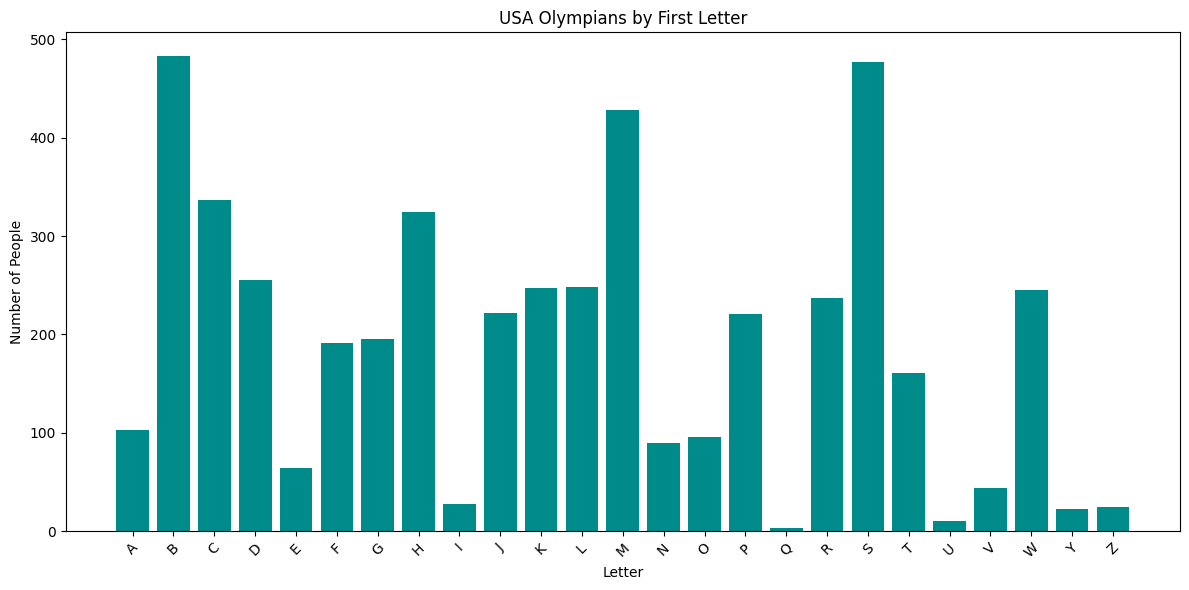

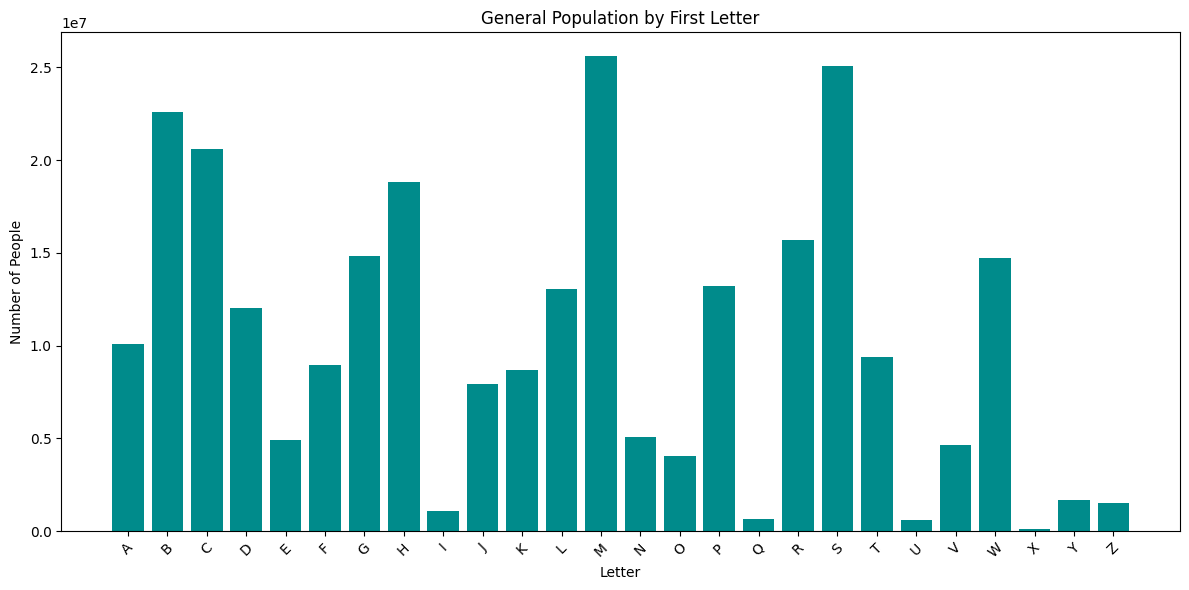

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

wolympics_df = pd.read_csv('../../07a_DOW3/data/winter_olympics_medals.csv')

usa_df = wolympics_df[wolympics_df['noc']=='USA'].copy()

def last_name_first_letter (name):
    parts = name.split()
    first_letter = parts[-1][0]
    return first_letter

usa_df['first_letter'] = usa_df['as'].apply(last_name_first_letter)

last_names_df = pd.read_csv('../../07a_DOW3/data/last_names.csv')
last_names_df['people_count'] = last_names_df['People'].str.replace(",","").astype(int)

last_names_sorted = last_names_df.sort_values('Letter')

general_counts = (
    last_names_sorted
    .set_index("Letter")["people_count"]
)

olympic_counts = (
    usa_df["first_letter"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,6))
plt.bar(olympic_counts.index, olympic_counts.values,
        color="darkcyan")
plt.xlabel("Letter")
plt.ylabel("Number of People")
plt.title("USA Olympians by First Letter")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
plt.bar(last_names_sorted["Letter"],
        last_names_sorted["people_count"],
        color="darkcyan")
plt.xlabel("Letter")
plt.ylabel("Number of People")
plt.title("General Population by First Letter")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

From these graphs alone, it can be tough to spot any sort of trend in the data. There are similar spikes in letters B, M, and S, and similar dips in Q, U, and X. It seems like there isn't a huge difference between the two samples. At least visually, the Olympians appear to mirror the broader U.S. population rather than cluster disproportionately at the front of the alphabet. If alphabetical advantage plays a role in elite athletic success, it’s not immediately obvious in the raw counts. To move beyond eyeballing bar charts, we’ll need to standardize these distributions and look at proportions rather than totals.

## Looking at Proportions and Winners

This time, we'll be comparing the U.S. Census data to the U.S. Olympic data as well as the medal winners within the Olympic data. Additionally, we'll chunk the alphabet into thirds (A-I, J-R, S-Z) to make any sort of distinction clearer.

In [21]:
medals = ['Gold', 'Silver', 'Bronze']
last_names_sorted_winners = usa_df[usa_df['medal'].isin(medals)].copy()

general_counts = (
    last_names_sorted
    .set_index("Letter")["people_count"]
)
general_props = general_counts / general_counts.sum()

olympic_counts = (
    usa_df["first_letter"]
    .value_counts()
    .sort_index()
)
olympic_props = olympic_counts / olympic_counts.sum()

winner_counts = (
    last_names_sorted_winners["first_letter"]
    .value_counts()
    .sort_index()
)
winner_props = winner_counts / winner_counts.sum()
comparison = pd.DataFrame({
    "General Population Proportion": general_props,
    "USA Olympians Proportion": olympic_props,
    "USA Medalist Proportion": winner_props
}).fillna(0)
comparison = (comparison * 100).round(1)
first_third = comparison.loc["A":"I"]
middle_third = comparison.loc["J":"R"]
last_third = comparison.loc["S":"Z"]
third_sums = pd.DataFrame({
    "General Population": [
        first_third["General Population Proportion"].sum(),
        middle_third["General Population Proportion"].sum(),
        last_third["General Population Proportion"].sum()
    ],
    "USA Olympians": [
        first_third["USA Olympians Proportion"].sum(),
        middle_third["USA Olympians Proportion"].sum(),
        last_third["USA Olympians Proportion"].sum()
    ],
    "USA Medalists": [
        first_third["USA Medalist Proportion"].sum(),
        middle_third["USA Medalist Proportion"].sum(),
        last_third["USA Medalist Proportion"].sum()
    ]
}, index=["A–I", "J–R", "S–Z"])
display(third_sums)

,General Population,USA Olympians,USA Medalists
A–I,42.9,41.7,42.3
J–R,35.3,37.7,38.7
S–Z,21.6,20.7,18.9


In the general population, 42.9 percent of last names fall in A–I, compared with 41.7 percent of Olympians and 42.3 percent of medalists. The front of the alphabet is not overrepresented among elite athletes; if anything, it approximates the national baseline. The middle third, J–R, on the other hand, is slightly more common among Olympians and medalists than in the general population. 

The back third, S–Z, shows an interesting trend. There is a slight decline in the proportion of people with last names starting with S-Z as we go from the general population to Olympians to Olympic medalists. The drop is modest, but it is the only segment that consistently decreases across each step of selection.

Still, the magnitude of that shift is small. A difference of two to three percentage points is hardly evidence of a structural alphabetical barrier to athletic success. If alphabetical advantage were meaningfully shaping outcomes, we would expect to see a much sharper front-loading effect among medalists. Instead, the overall distribution remains remarkably stable.

## Conclusion

Taken together, the data suggest that last-name initials do not meaningfully predict who makes it to the Winter Olympics — or who wins once they get there. While alphabetical order may subtly influence classroom dynamics or early career visibility, it does not appear to sort athletes onto the podium. In this arena, performance seems to outweigh placement in the alphabet. 

In [22]:
latest_letter = last_names_sorted_winners['first_letter'].max()
latest_medalists = last_names_sorted_winners[
    last_names_sorted_winners['first_letter'] == latest_letter
]
display(latest_medalists)

,year,type,discipline,event,as,athlete_id,noc,team,place,tied,medal,first_letter
7694,1992.0,Winter,Short Track Speed Skating (Skating),"3,000 metres Relay, Women (Olympic)",Nikki Ziegelmeyer,83119,USA,United States,2.0,False,Silver,Z
7695,1994.0,Winter,Short Track Speed Skating (Skating),"3,000 metres Relay, Women (Olympic)",Nikki Ziegelmeyer,83119,USA,United States,3.0,False,Bronze,Z
47212,2010.0,Winter,Ice Hockey (Ice Hockey),"Ice Hockey, Women (Olympic)",Jinelle Zaugg-Siergiej,119239,USA,United States,2.0,False,Silver,Z
58163,2022.0,Winter,Figure Skating (Skating),"Team, Mixed (Olympic)",Vincent Zhou,138309,USA,United States,2.0,False,Silver,Z


So, even if your name is Nikki Ziegelmeyer or Jinelle Zaugg-Siergiej or Vincent Zhou, you can still work all the way to the Olympic podium!